In [2]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
)

pd.set_option('display.max_columns', None)


In [3]:
path = "/content/Food_Delivery_Time_Prediction.csv"
data = pd.read_csv(path)
data.head()


,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

In [5]:
data.describe(include='all')

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
count,200,200,200,200.000000,200,200,200.000000,200,200,200,200.000000,200.000000,200.000000,200.000000,200.000000
unique,200,200,200,NaN,4,3,NaN,3,4,3,NaN,NaN,NaN,NaN,NaN
top,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",NaN,Rainy,Low,NaN,Low,Afternoon,Bike,NaN,NaN,NaN,NaN,NaN
freq,1,1,1,NaN,57,81,NaN,75,59,69,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,11.498050,NaN,NaN,5.250000,NaN,NaN,NaN,3.738500,3.686500,70.494950,1046.488700,46.616650
std,NaN,NaN,NaN,6.841755,NaN,NaN,2.745027,NaN,NaN,NaN,0.703021,0.697063,29.830694,548.568922,29.361706
min,NaN,NaN,NaN,0.520000,NaN,NaN,1.000000,NaN,NaN,NaN,2.500000,2.600000,15.230000,122.300000,1.240000
25%,NaN,NaN,NaN,6.090000,NaN,NaN,3.000000,NaN,NaN,NaN,3.200000,3.100000,46.997500,553.270000,21.602500
50%,NaN,NaN,NaN,10.265000,NaN,NaN,5.000000,NaN,NaN,NaN,3.800000,3.700000,72.775000,1035.950000,47.530000
75%,NaN,NaN,NaN,16.497500,NaN,NaN,8.000000,NaN,NaN,NaN,4.300000,4.300000,96.650000,1543.125000,70.245000


In [6]:
print("Missing values per column:")
data.isnull().sum()

Missing values per column:


,0
Order_ID,0
Customer_Location,0
Restaurant_Location,0
Distance,0
Weather_Conditions,0
Traffic_Conditions,0
Delivery_Person_Experience,0
Order_Priority,0
Order_Time,0
Vehicle_Type,0


In [7]:
if "Delivery_Time" in data.columns:
    data = data.dropna(subset=["Delivery_Time"])

numeric_cols_all = data.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_all = data.select_dtypes(include=["object"]).columns.tolist()

for col in numeric_cols_all:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].median())

for col in categorical_cols_all:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].mode()[0])

print("Missing values after imputation:")
print(data.isnull().sum().sum(), "total missing values remain")


Missing values after imputation:
0 total missing values remain


In [8]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def try_parse_latlong(series):
    try:
        split = series.astype(str).str.split(",", expand=True)
        lat = split[0].astype(float)
        lon = split[1].astype(float)
        return lat, lon
    except Exception:
        return None

if "Customer_Location" in data.columns and "Restaurant_Location" in data.columns:
    cust = try_parse_latlong(data["Customer_Location"])
    rest = try_parse_latlong(data["Restaurant_Location"])
    if cust is not None and rest is not None:
        data["Distance_Haversine_km"] = haversine(cust[0], cust[1], rest[0], rest[1])
        print("Computed Haversine distance from Customer_Location / Restaurant_Location.")
        print(data[["Customer_Location", "Restaurant_Location", "Distance_Haversine_km"]].head())
    else:
        print("Location columns present but not in a parseable 'lat,long' format — skipping Haversine calc, keeping existing Distance column.")
else:
    print("No separate lat/long location columns found — using the existing 'Distance' column as-is.")


Location columns present but not in a parseable 'lat,long' format — skipping Haversine calc, keeping existing Distance column.


In [9]:
categorical_to_encode = [
    "Weather_Conditions", "Traffic_Conditions", "Order_Priority", "Order_Time", "Vehicle_Type"
]
categorical_to_encode = [c for c in categorical_to_encode if c in data.columns]

data = pd.get_dummies(data, columns=categorical_to_encode, dtype=int)
data.head()


,Order_ID,Customer_Location,Restaurant_Location,Distance,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Traffic_Conditions_High,Traffic_Conditions_Low,Traffic_Conditions_Medium,Order_Priority_High,Order_Priority_Low,Order_Priority_Medium,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,4,4.1,3.0,26.22,1321.10,81.54,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,0,1
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,8,4.5,4.2,62.61,152.21,29.02,1,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,1
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,9,3.3,3.4,48.43,1644.38,64.17,0,0,1,0,0,0,1,1,0,0,0,0,0,1,0,1,0
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,2,3.2,3.7,111.63,541.25,79.23,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,6,3.5,2.8,32.38,619.81,2.34,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,1,0


In [10]:
cols_to_drop = [c for c in ["Order_ID", "Customer_Location", "Restaurant_Location"] if c in data.columns]
data = data.drop(columns=cols_to_drop)
data.head()


,Distance,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Traffic_Conditions_High,Traffic_Conditions_Low,Traffic_Conditions_Medium,Order_Priority_High,Order_Priority_Low,Order_Priority_Medium,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car
0,1.57,4,4.1,3.0,26.22,1321.10,81.54,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,0,1
1,21.32,8,4.5,4.2,62.61,152.21,29.02,1,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,1
2,6.95,9,3.3,3.4,48.43,1644.38,64.17,0,0,1,0,0,0,1,1,0,0,0,0,0,1,0,1,0
3,13.79,2,3.2,3.7,111.63,541.25,79.23,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0
4,6.72,6,3.5,2.8,32.38,619.81,2.34,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,1,0


In [11]:
numeric_features = [c for c in [
    "Distance", "Distance_Haversine_km", "Delivery_Person_Experience",
    "Restaurant_Rating", "Customer_Rating", "Order_Cost", "Tip_Amount"
] if c in data.columns]

scaler = StandardScaler()
scaled_values = scaler.fit_transform(data[numeric_features])
scaled_df = pd.DataFrame(scaled_values, columns=[f"{c}_scaled" for c in numeric_features], index=data.index)

data = pd.concat([data, scaled_df], axis=1)
data[numeric_features + [f"{c}_scaled" for c in numeric_features]].describe()


,Distance,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Order_Cost,Tip_Amount,Distance_scaled,Delivery_Person_Experience_scaled,Restaurant_Rating_scaled,Customer_Rating_scaled,Order_Cost_scaled,Tip_Amount_scaled
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02
mean,11.498050,5.250000,3.738500,3.686500,1046.488700,46.616650,-1.643130e-16,4.440892e-18,3.463896e-16,4.529710e-16,-2.042810e-16,-4.440892e-18
std,6.841755,2.745027,0.703021,0.697063,548.568922,29.361706,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00
min,0.520000,1.000000,2.500000,2.600000,122.300000,1.240000,-1.608593e+00,-1.552139e+00,-1.766103e+00,-1.562593e+00,-1.688954e+00,-1.549315e+00
25%,6.090000,3.000000,3.200000,3.100000,553.270000,21.602500,-7.924313e-01,-8.217208e-01,-7.679018e-01,-8.434984e-01,-9.013569e-01,-8.540689e-01
50%,10.265000,5.000000,3.800000,3.700000,1035.950000,47.530000,-1.806765e-01,-9.130231e-02,8.769909e-02,1.941556e-02,-1.925947e-02,3.118490e-02
75%,16.497500,8.000000,4.300000,4.300000,1543.125000,70.245000,7.325599e-01,1.004325e+00,8.006998e-01,8.823295e-01,9.076026e-01,8.067529e-01
max,24.900000,10.000000,5.000000,5.000000,1997.420000,99.740000,1.963762e+00,1.734744e+00,1.798901e+00,1.889062e+00,1.737826e+00,1.813813e+00


In [12]:
corr_matrix = data.corr(numeric_only=True)
if "Delivery_Time" in corr_matrix.columns:
    print(corr_matrix["Delivery_Time"].sort_values(ascending=False))


Delivery_Time                        1.000000
Vehicle_Type_Bicycle                 0.093194
Weather_Conditions_Rainy             0.054402
Traffic_Conditions_Low               0.039714
Order_Priority_Low                   0.012849
Order_Time_Morning                   0.011984
Traffic_Conditions_Medium            0.011810
Order_Time_Afternoon                 0.006363
Order_Priority_High                  0.004804
Vehicle_Type_Car                    -0.001372
Order_Time_Evening                  -0.004021
Order_Cost                          -0.009307
Order_Cost_scaled                   -0.009307
Weather_Conditions_Cloudy           -0.012272
Order_Time_Night                    -0.013972
Order_Priority_Medium               -0.017798
Delivery_Person_Experience          -0.019098
Delivery_Person_Experience_scaled   -0.019098
Weather_Conditions_Sunny            -0.020492
Customer_Rating                     -0.021952
Customer_Rating_scaled              -0.021952
Weather_Conditions_Snowy          

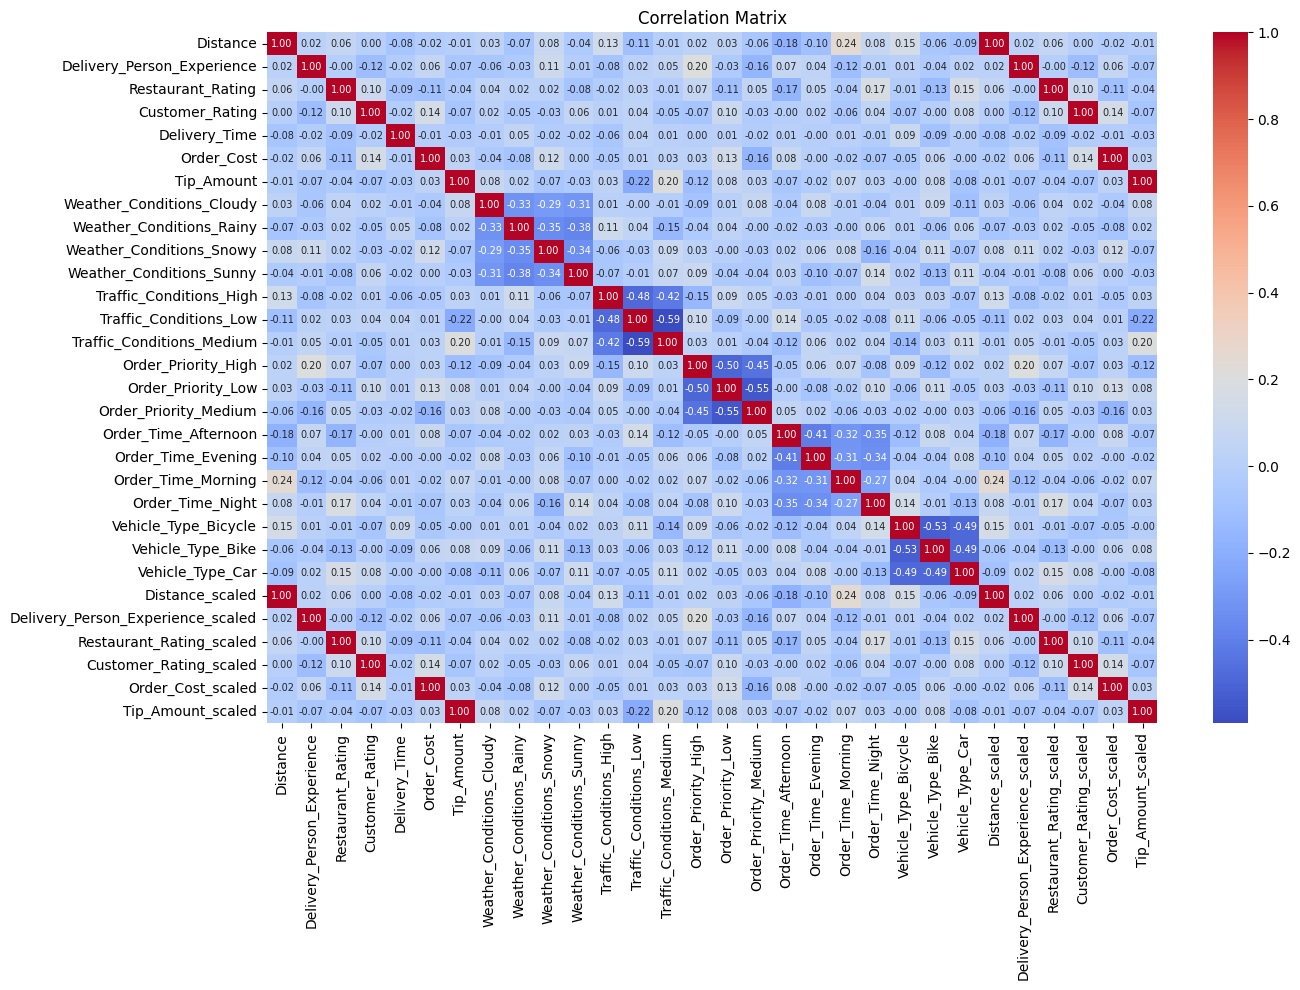

In [13]:
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 7})
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


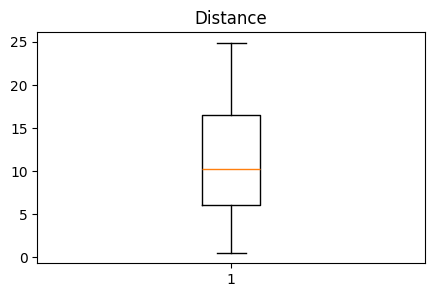

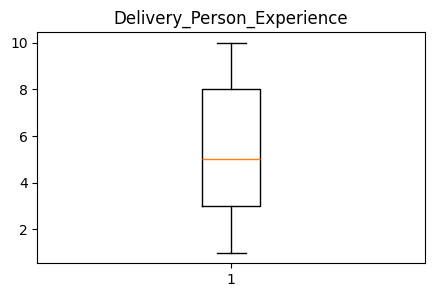

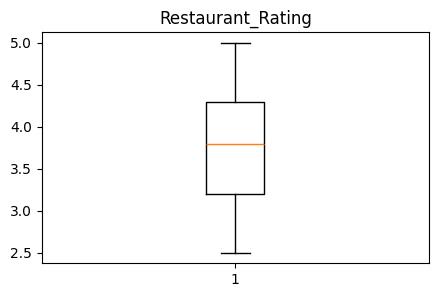

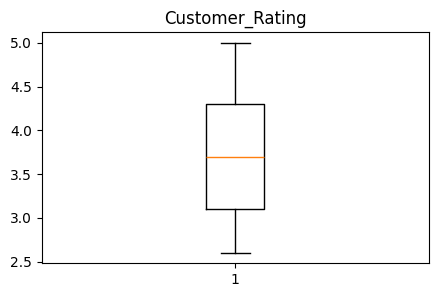

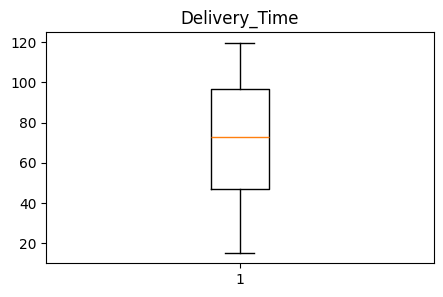

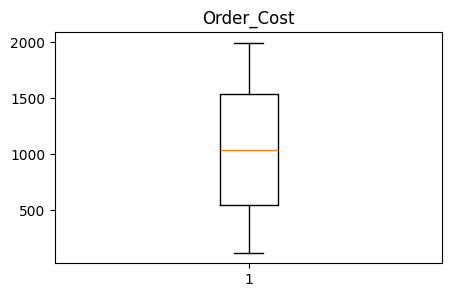

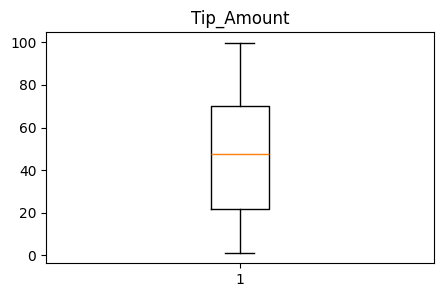

In [14]:
num_cols = [c for c in [
    "Distance", "Delivery_Person_Experience", "Restaurant_Rating",
    "Customer_Rating", "Delivery_Time", "Order_Cost", "Tip_Amount"
] if c in data.columns]

for col in num_cols:
    plt.figure(figsize=(5, 3))
    plt.boxplot(data[col].dropna())
    plt.title(col)
    plt.show()


In [15]:
before_rows = len(data)
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data = data[(data[col] >= lower) & (data[col] <= upper)]

print(f"Removed {before_rows - len(data)} outlier rows ({before_rows} -> {len(data)}).")
data.describe()


Removed 0 outlier rows (200 -> 200).


,Distance,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Traffic_Conditions_High,Traffic_Conditions_Low,Traffic_Conditions_Medium,Order_Priority_High,Order_Priority_Low,Order_Priority_Medium,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car,Distance_scaled,Delivery_Person_Experience_scaled,Restaurant_Rating_scaled,Customer_Rating_scaled,Order_Cost_scaled,Tip_Amount_scaled
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02
mean,11.498050,5.250000,3.738500,3.686500,70.494950,1046.488700,46.616650,0.21000,0.285000,0.240000,0.265000,0.255000,0.405000,0.340000,0.290000,0.375000,0.335000,0.295000,0.285000,0.195000,0.22500,0.345000,0.345000,0.310000,-1.643130e-16,4.440892e-18,3.463896e-16,4.529710e-16,-2.042810e-16,-4.440892e-18
std,6.841755,2.745027,0.703021,0.697063,29.830694,548.568922,29.361706,0.40833,0.452547,0.428155,0.442441,0.436955,0.492124,0.474898,0.454901,0.485338,0.473175,0.457187,0.452547,0.397195,0.41863,0.476561,0.476561,0.463654,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00
min,0.520000,1.000000,2.500000,2.600000,15.230000,122.300000,1.240000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-1.608593e+00,-1.552139e+00,-1.766103e+00,-1.562593e+00,-1.688954e+00,-1.549315e+00
25%,6.090000,3.000000,3.200000,3.100000,46.997500,553.270000,21.602500,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-7.924313e-01,-8.217208e-01,-7.679018e-01,-8.434984e-01,-9.013569e-01,-8.540689e-01
50%,10.265000,5.000000,3.800000,3.700000,72.775000,1035.950000,47.530000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-1.806765e-01,-9.130231e-02,8.769909e-02,1.941556e-02,-1.925947e-02,3.118490e-02
75%,16.497500,8.000000,4.300000,4.300000,96.650000,1543.125000,70.245000,0.00000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,1.000000,1.000000,1.000000,7.325599e-01,1.004325e+00,8.006998e-01,8.823295e-01,9.076026e-01,8.067529e-01
max,24.900000,10.000000,5.000000,5.000000,119.670000,1997.420000,99.740000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.963762e+00,1.734744e+00,1.798901e+00,1.889062e+00,1.737826e+00,1.813813e+00


In [16]:
rush_cols = [c for c in ["Order_Time_Morning", "Order_Time_Evening"] if c in data.columns]

if rush_cols:
    data["Rush_Hour"] = data[rush_cols].sum(axis=1).astype(int)
    print(data[rush_cols + ["Rush_Hour"]].head())
else:
    print("Order_Time dummy columns not found — skipping Rush_Hour feature.")


   Order_Time_Morning  Order_Time_Evening  Rush_Hour
0                   0                   0          0
1                   0                   0          0
2                   0                   0          0
3                   0                   1          1
4                   0                   0          0


In [17]:
traffic_cols = [c for c in data.columns if c.startswith("Traffic_Conditions_")]
priority_cols = [c for c in data.columns if c.startswith("Order_Priority_")]
distance_col = "Distance_scaled" if "Distance_scaled" in data.columns else "Distance"

feature_cols_lr = [distance_col] + traffic_cols + priority_cols
print("Linear Regression features:", feature_cols_lr)

X = data[feature_cols_lr]
y = data["Delivery_Time"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Linear Regression features: ['Distance_scaled', 'Traffic_Conditions_High', 'Traffic_Conditions_Low', 'Traffic_Conditions_Medium', 'Order_Priority_High', 'Order_Priority_Low', 'Order_Priority_Medium']


In [18]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)


LinearRegression()

In [19]:
y_pred_lr = lin_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression Results")
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Mean Absolute Error:", mae)


Linear Regression Results
Mean Squared Error: 915.3719745504928
R-squared: 0.010292275231804426
Mean Absolute Error: 25.48472806891557


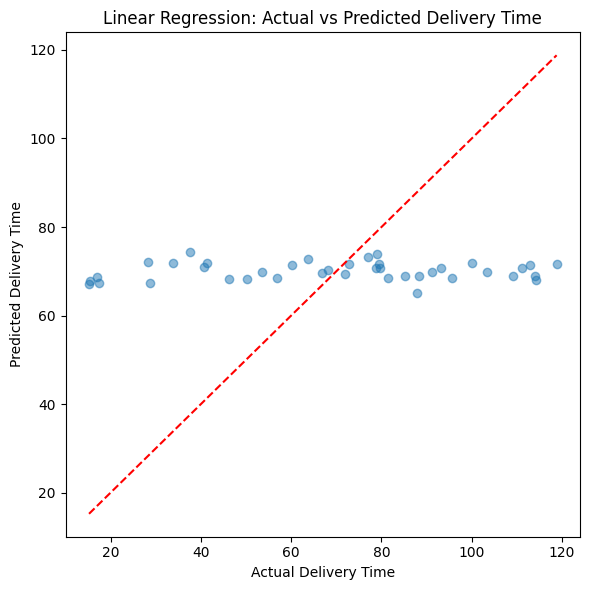

In [20]:

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
lims = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Linear Regression: Actual vs Predicted Delivery Time")
plt.tight_layout()
plt.show()


In [21]:
DELAY_THRESHOLD_MIN = 30

data["Delivery_Status"] = (data["Delivery_Time"] > DELAY_THRESHOLD_MIN).astype(int)
print(data["Delivery_Status"].value_counts())
print("\n0 = Fast (<= {} min), 1 = Delayed (> {} min)".format(DELAY_THRESHOLD_MIN, DELAY_THRESHOLD_MIN))


Delivery_Status
1    174
0     26
Name: count, dtype: int64

0 = Fast (<= 30 min), 1 = Delayed (> 30 min)


In [22]:

drop_for_clf = [c for c in ["Delivery_Status", "Delivery_Time"] if c in data.columns]
X_clf = data.drop(columns=drop_for_clf)
y_clf = data["Delivery_Status"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)


In [23]:
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_c, y_train_c)


LogisticRegression(max_iter=2000)

In [24]:
y_pred_c = log_model.predict(X_test_c)

accuracy = accuracy_score(y_test_c, y_pred_c)
precision = precision_score(y_test_c, y_pred_c, zero_division=0)
recall = recall_score(y_test_c, y_pred_c, zero_division=0)
f1 = f1_score(y_test_c, y_pred_c, zero_division=0)
conf_matrix = confusion_matrix(y_test_c, y_pred_c)

print("Logistic Regression Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", conf_matrix)


Logistic Regression Results
Accuracy: 0.875
Precision: 0.875
Recall: 1.0
F1 Score: 0.9333333333333333
Confusion Matrix:
 [[ 0  5]
 [ 0 35]]


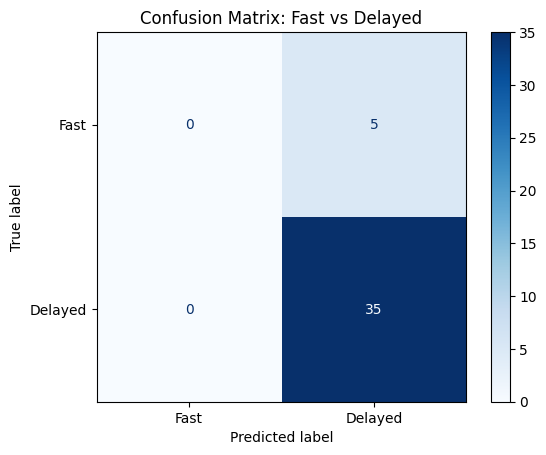

In [25]:
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Fast", "Delayed"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Fast vs Delayed")
plt.show()


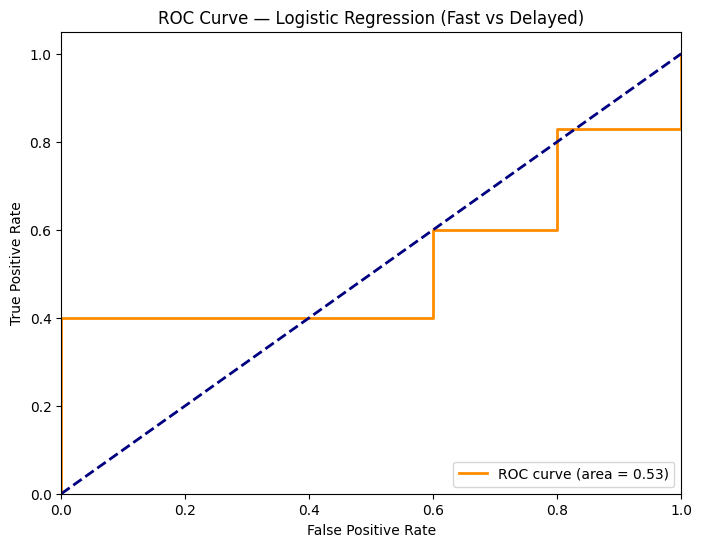

In [26]:
y_pred_proba = log_model.predict_proba(X_test_c)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_c, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression (Fast vs Delayed)')
plt.legend(loc="lower right")
plt.show()


In [27]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression (Delivery_Time)", "Logistic Regression (Fast/Delayed)"],
    "Primary Metric": [f"R-squared = {r2:.3f}", f"Accuracy = {accuracy:.3f}"],
    "Secondary Metric": [f"MAE = {mae:.2f} min", f"F1 = {f1:.3f}"],
})
comparison


,Model,Primary Metric,Secondary Metric
0,Linear Regression (Delivery_Time),R-squared = 0.010,MAE = 25.48 min
1,Logistic Regression (Fast/Delayed),Accuracy = 0.875,F1 = 0.933
